In [321]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

df = pd.read_csv("GEDEvent_v25_1.csv")

C:\Users\tolot\AppData\Local\Temp\ipykernel_27044\2293759986.py:7: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("GEDEvent_v25_1.csv")


## <font color="#cc00ff"> Data Analysis and Preprocessing Workflow </font>

### **1. Data Exploration and Understanding**
- Load the provided dataset and perform an exploratory data analysis (EDA).
- Describe the main characteristics of the dataset, including:
  - Number of observations
  - Number of variables
  - Data types
- Detect errors, outliers (anomalies), and missing values.

### **2. Data Visualization**
- Apply appropriate visualization techniques to highlight key dataset characteristics.
- Ensure visualizations are clear, concise, and effective.
- Interpret the insights obtained from the visualizations.
- Identify general patterns and distributions.

### **3. Supervised Machine Learning Problem Definition**
- Define a potential supervised ML problem based on the dataset.
- Specify whether it is a classification or regression task.
- Clearly define the target variable.

### **4. Data Cleaning and Preprocessing**
- Analyze the type of missing data: MCAR, MAR, or MNAR.
- Perform general data cleaning by removing or correcting inconsistent or irrelevant data.
- Split the dataset (e.g., train and test sets).
- Identify and handle missing values.
- Detect and treat outliers using appropriate statistical or visualization methods.
- Scale and/or normalize features.

### **5. Feature Engineering**
- Create new features if necessary and justify their inclusion.
- Apply variable transformation techniques such as:
  - Encoding (categorical variables)
  - Discretization
- Analyze class balance (for classification problems).
- Apply balancing techniques if needed and justify the approach.

### **6. Dimensionality Reduction**
- Evaluate relationships between variables and perform feature selection (e.g., filter methods).
- Implement feature extraction techniques (e.g., PCA).
- Analyze the advantages and disadvantages of dimensionality reduction.

##  <font color="#fbff00">1. Exploration </font>

###  <font color="#ff8800"> Basic Description </font>

In [322]:
print("=== First rows ===")
display(df.head(3))

=== First rows ===


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,dyad_new_id,dyad_name,side_a_dset_id,side_a_new_id,side_a,side_b_dset_id,side_b_new_id,side_b,number_of_sources,source_article,source_office,source_date,source_headline,source_original,where_prec,where_coordinates,where_description,adm_1,adm_2,latitude,longitude,geom_wkt,priogrid_gid,country,country_id,region,event_clarity,date_prec,date_start,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,3,"""Agence France Presse,2017-08-01,At least 20 k...",Agence France Presse;Agence France Presse;Pajh...,2017-08-01;2017-08-01;2017-07-31,At least 20 killed in Shiite mosque attack in ...,"IS, interior ministry, security source",1,Kabul city,Iraqi embassy in Kabul,Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,1,2017-07-31 00:00:00.000,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,15,"""BBC News,2021-08-26,Explosion at Kabul airpor...",BBC News;ShamshadNews on Twitter;Xinhua News A...,2021-08-26;2021-08-26;2021-08-30;2021-08-27;20...,Explosion at Kabul airport;At least 11 people ...,US officials; Taliban spokesman Zabihullah Muj...,1,Kabul international airport,Kabul airport (Abbey gate entrance),Kabul province,Kabul district,34.564444,69.217222,POINT (69.2172222 34.5644444),179779,Afghanistan,700,Asia,1,1,2021-08-26 00:00:00.000,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,5,"""Khaama Press,2021-08-28,First US airstrike hi...",Khaama Press;Reuters News;Agence France Presse...,2021-08-28;2021-08-28;2021-08-28;2021-08-28;20...,First US airstrike hits ISIS-K fighter after T...,US central command spokesperson Captain Bill U...,1,Jalalabad town,Police District 7 of Jalalabad city,Nangarhar province,Jalalabad district,34.428844,70.455750,POINT (70.45575 34.428844),179061,Afghanistan,700,Asia,1,1,2021-08-28 00:00:00.000,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN


In [323]:
print("\n=== Dataset Shape (rows, columns) ===")
display(df.shape)

print("\n=== Dataset Columns ===")
display(df.columns)




=== Dataset Shape (rows, columns) ===


(385918, 49)


=== Dataset Columns ===


Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')

In [324]:
# Numerical columns summary
print("\n=== Summary Statistics (Numerical Columns) ===")
df.describe().round(2)


=== Summary Statistics (Numerical Columns) ===


,id,year,type_of_violence,conflict_dset_id,conflict_new_id,dyad_dset_id,dyad_new_id,side_a_dset_id,side_a_new_id,side_b_dset_id,side_b_new_id,number_of_sources,where_prec,latitude,longitude,priogrid_gid,country_id,event_clarity,date_prec,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnob
count,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,30256.00
mean,290595.57,2012.49,1.45,3876.81,3893.46,6744.22,6993.74,633.19,633.19,3296.49,1752.30,0.82,2.05,26.09,29.65,167265.53,544.63,1.08,1.22,2.47,2.25,3.82,1.72,10.25,15.12,8.54,389.52
std,158412.34,9.41,0.75,5885.53,5774.83,6468.05,6475.38,1705.34,1705.34,3658.77,2396.03,1.65,1.26,16.05,49.51,23136.21,212.16,0.27,0.65,254.72,53.76,178.40,99.62,347.68,426.86,313.66,85.85
min,2.00,1989.00,1.00,6.00,205.00,6.00,406.00,3.00,3.00,3.00,1.00,-1.00,1.00,-37.81,-117.30,75530.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
25%,162928.25,2007.00,1.00,299.00,299.00,735.00,781.00,109.00,109.00,303.00,208.00,-1.00,1.00,13.36,29.17,148769.00,372.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,369.00
50%,293210.50,2014.00,1.00,333.00,386.00,5188.00,5226.00,118.00,118.00,775.00,338.00,1.00,2.00,33.00,37.05,177551.00,652.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,2.00,2.00,369.00
75%,422042.75,2020.00,2.00,5583.00,4979.00,14117.00,14117.00,154.00,154.00,5914.00,4456.00,1.00,3.00,35.78,62.20,181154.00,700.00,1.00,1.00,0.00,1.00,1.00,0.00,4.00,5.00,4.00,369.00
max,572006.00,2024.00,3.00,18362.00,16527.00,18362.00,18362.00,9363.00,9363.00,9999.00,9392.00,361.00,7.00,68.98,155.90,228667.00,940.00,2.00,5.00,121848.00,19874.00,40000.00,48183.00,121848.00,121848.00,121848.00,800.00


In [325]:
df.describe(include='string').T

,count,unique,top,freq
relid,385918,385918,IRQ-2017-1-524-322,1
code_status,385918,1,Clear,385918
conflict_name,385918,1529,Syria: Government,66186
dyad_name,385918,1771,Government of Syria - Syrian insurgents,66186
side_a,385918,966,Government of Syria,75181
side_b,385918,959,Syrian insurgents,66186
source_article,385917,255147,"""Balkan Battlegrounds: A Military History of t...",4123
source_office,288005,24027,SOHR,29640
source_date,288005,48785,2002-11-01;2012-11-01,5410
source_headline,288000,185443,Volume I and II;Bosnian Book of the Dead,4127


###  <font color="#ff8800"> Feature Type Count </font>

In [326]:
# Conteo de tipos de variables

print("\n=== Conteo de tipos de variables ===")
display(df.dtypes.value_counts())

print("\n=== Variables numéricas ===")
display(df.select_dtypes(include=["number"]).columns)

print("\n=== Variables categóricas ===")
display(df.select_dtypes(include=["object", "category", "string"]).columns)

print("\n=== Variables booleanas ===")
display(df.select_dtypes(include=["bool"]).columns)

print("\n=== Variables de fecha ===")
display(df.select_dtypes(include=["datetime"]).columns)


=== Conteo de tipos de variables ===


int64      24
str        20
float64     3
bool        1
object      1
Name: count, dtype: int64


=== Variables numéricas ===


Index(['id', 'year', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id',
       'dyad_dset_id', 'dyad_new_id', 'side_a_dset_id', 'side_a_new_id',
       'side_b_dset_id', 'side_b_new_id', 'number_of_sources', 'where_prec',
       'latitude', 'longitude', 'priogrid_gid', 'country_id', 'event_clarity',
       'date_prec', 'deaths_a', 'deaths_b', 'deaths_civilians',
       'deaths_unknown', 'best', 'high', 'low', 'gwnob'],
      dtype='str')


=== Variables categóricas ===


Index(['relid', 'code_status', 'conflict_name', 'dyad_name', 'side_a',
       'side_b', 'source_article', 'source_office', 'source_date',
       'source_headline', 'source_original', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'geom_wkt', 'country', 'region',
       'date_start', 'date_end', 'gwnoa'],
      dtype='str')


=== Variables booleanas ===


Index(['active_year'], dtype='str')


=== Variables de fecha ===


Index([], dtype='str')

###  <font color="#ff8800"> Errors, Outliers and Missing Values </font>

In [327]:
# Duplicates
print("=== Duplicated rows ===")
duplicados = df.duplicated().sum()
print("Duplicated rows amount:", duplicados)

# Missing values
print("\n=== Missing Values ===")
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data.reset_index().rename(columns={'index': 'Column'})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)

# IQR Outliers
print("\n=== Numeric Features Outliers ===")
df_num = df.select_dtypes(include="number")

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))

# Filter columns with more than 10% outliers

outliers_data = pd.DataFrame({
    'Outliers_count': outliers_mask.sum(),
    'Outliers_Percentage': (outliers_mask.sum() / len(df) * 100).round(2)
})

outliers_data = outliers_data.reset_index().rename(columns={'index': 'Column'})

outliers_data = outliers_data[outliers_data['Outliers_Percentage'] > 10].sort_values('Outliers_count', ascending=False)
print(outliers_data.head(10))


=== Duplicated rows ===
Duplicated rows amount: 0

=== Missing Values ===
               Column  Missing_Count  Missing_Percentage
48              gwnob         355662               92.16
22    source_headline          97918               25.37
21        source_date          97913               25.37
20      source_office          97913               25.37
47              gwnoa          93411               24.20
28              adm_2          69977               18.13
23    source_original          44244               11.46
27              adm_1          19547                5.07
26  where_description          10243                2.65
19     source_article              1                0.00

=== Numeric Features Outliers ===
              Column  Outliers_count  Outliers_Percentage
7     side_a_dset_id          102119                26.46
8      side_a_new_id          102119                26.46
19          deaths_a           94908                24.59
4    conflict_new_id           9

In [328]:
# Remove ID-like columns
df_num = df_num.loc[:, ~df_num.columns.str.contains('id', case=False)]

# Compute IQR
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

# Outlier mask
outliers_mask = ((df_num < (Q1 - 1.5 * IQR)) | 
                 (df_num > (Q3 + 1.5 * IQR)))

# Summary table
outliers_data = pd.DataFrame({
    'Outliers_count': outliers_mask.sum(),
    'Outliers_Percentage': (outliers_mask.sum() / len(df) * 100).round(2)
})

outliers_data = outliers_data.reset_index().rename(columns={'index': 'Column'})

outliers_data = outliers_data[outliers_data['Outliers_Percentage'] > 10].sort_values('Outliers_count', ascending=False)
print("\n=== Numeric Features Outliers Without ID Columns ===")
print(outliers_data.head(10))


=== Numeric Features Outliers Without ID Columns ===
              Column  Outliers_count  Outliers_Percentage
8           deaths_a           94908                24.59
7          date_prec           57245                14.83
9           deaths_b           57128                14.80
11    deaths_unknown           56401                14.61
5          longitude           54154                14.03
12              best           50210                13.01
14               low           46614                12.08
13              high           45916                11.90
10  deaths_civilians           40484                10.49


## <font color="#cc00ff"> Dataset Summary – Exploratory Data Analysis (EDA) </font>

---

## General Overview

**Dataset size:** 385,918 rows × 49 columns

### Variable Types

| Type                  | Count |
|-----------------------|-------|
| Numerical (int64)     | 24    |
| Categorical / String  | 20    |
| Float (float64)       | 3     |
| Boolean               | 1     |
| Object                | 1     |

---

## Key Features

- **Numerical variables:**  
  `type_of_violence`, `number_of_sources`, `where_prec`, `event_clarity`, `date_prec`,  
  `best`, `deaths_a`, `deaths_b`, `deaths_civilians`, `deaths_unknown`, among others.

- **Categorical variables:**  
  `source_date`, `where_coordinates`, `where_description`, `country`, `region`,  
  `date_start`, `date_end`, among others.

---

## Missing Values

The dataset contains several variables with a high proportion of missing data:

| Variable           | Missing (%) |
|------------------|-------------|
| gwnob             | 92.16%      |
| source_office     | 25.37%      |
| source_date       | 25.37%      |
| source_headline   | 25.37%      |
| gwnoa             | 24.20%      |
| adm_2             | 18.13%      |

---

## Data Quality Insights

- No duplicated rows were found in the dataset.
- Several numerical variables exhibit a significant presence of outliers, particularly:
  - `deaths_a`
  - `deaths_b`
  - `deaths_unknown`
  - `deaths_civilians`
  - `best`, `high`, and `low`

These outliers are expected given the nature of the data (conflict-related events), but they should be carefully analyzed before modeling.

---

## Initial Observations

- The dataset is large and rich in both numerical and categorical information.
- Some variables (e.g., `gwnob`) contain excessive missing values and may require removal or special treatment.
- Features related to fatalities show high variability and extreme values, which could strongly influence model performance.

##  <font color="#fbff00">2. Data Visualization </font>

###  <font color="#ff8800"> Feature Selection and Removal Rationale </font>

 <font color="#ff0000"> **IMPORTANT**  </font>

Several variables were removed from the dataset prior to analysis in order to improve data quality, interpretability, and modeling relevance.

#### Deprecated and Non-Operational Variables
The following variables were explicitly documented as deprecated or not intended for use in the current dataset version (UCDP GED 25.1 API):

- relid  
- code_status  
- conflict_dset_id  
- dyad_dset_id  
- side_a_dset_id  
- side_b_dset_id  

These variables are either legacy identifiers from previous dataset versions or internal-use fields with no analytical relevance. Including them could introduce noise or confusion without contributing meaningful information.

#### Geospatial and Technical Representation Features

- priogrid_gid  
- geom_wkt  

Although these variables contain spatial information, they were removed for the following reasons:
  
- **priogrid_gid** is a spatial indexing reference tied to an external grid system (PRIO-GRID), which requires additional datasets and careful handling to avoid inconsistencies.
  
- **geom_wkt** is a technical geometric representation intended for GIS systems, not for statistical analysis.

Since this analysis does not focus on spatial modeling, these variables were excluded to maintain clarity and avoid introducing misleading patterns.


In [ ]:
drop_cols = [
    'relid',
    'code_status',
    'conflict_dset_id',
    'dyad_dset_id',
    'side_a_dset_id',
    'side_b_dset_id',
    'priogrid_gid',
    'geom_wkt'
]

df = df.drop(columns=drop_cols,errors='ignore')


=== Dataset Shape (rows, columns) ===


(385918, 41)


=== Dataset Columns ===


Index(['id', 'year', 'active_year', 'type_of_violence', 'conflict_new_id',
       'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a',
       'side_b_new_id', 'side_b', 'number_of_sources', 'source_article',
       'source_office', 'source_date', 'source_headline', 'source_original',
       'where_prec', 'where_coordinates', 'where_description', 'adm_1',
       'adm_2', 'latitude', 'longitude', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')


=== Conteo de tipos de variables ===


int64      19
str        17
float64     3
bool        1
object      1
Name: count, dtype: int64

###  <font color="#ff8800"> Outliers and Missing Values </font>

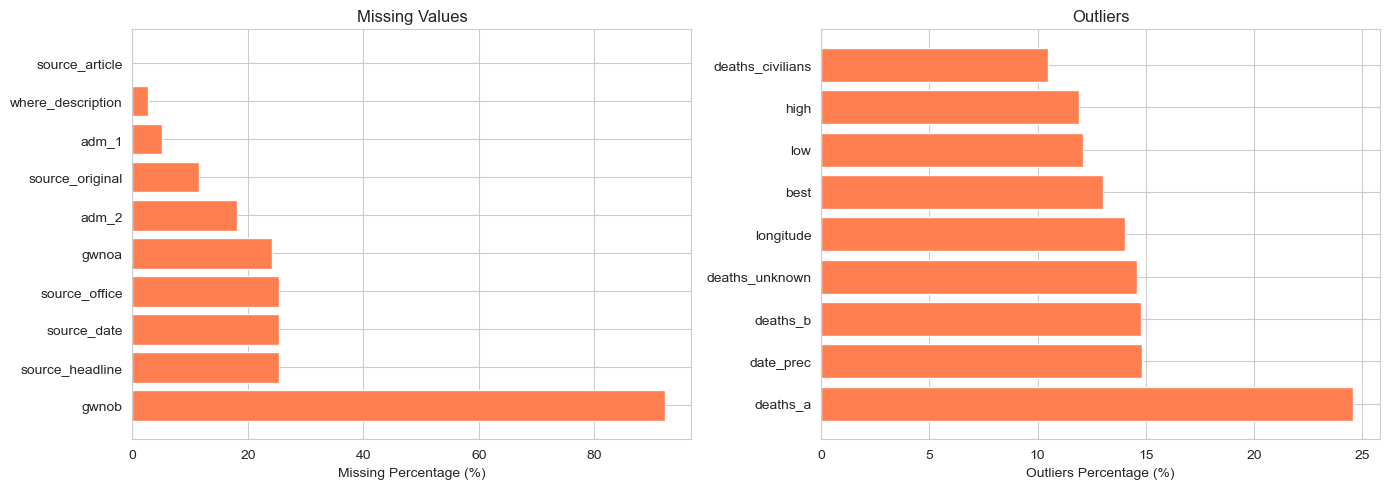

In [361]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Missing values
# -------------------------
ax1.barh(
    missing_data['Column'],
    missing_data['Missing_Percentage'],
    color='coral'
)
ax1.set_xlabel('Missing Percentage (%)')
ax1.set_title('Missing Values')

# -------------------------
# Outliers
# -------------------------
ax2.barh(
    outliers_data['Column'],
    outliers_data['Outliers_Percentage'],
    color='coral'
)
ax2.set_xlabel('Outliers Percentage (%)')
ax2.set_title('Outliers')

plt.tight_layout()
plt.show()

#### **top 5 columns with the highest percentage of outliers**

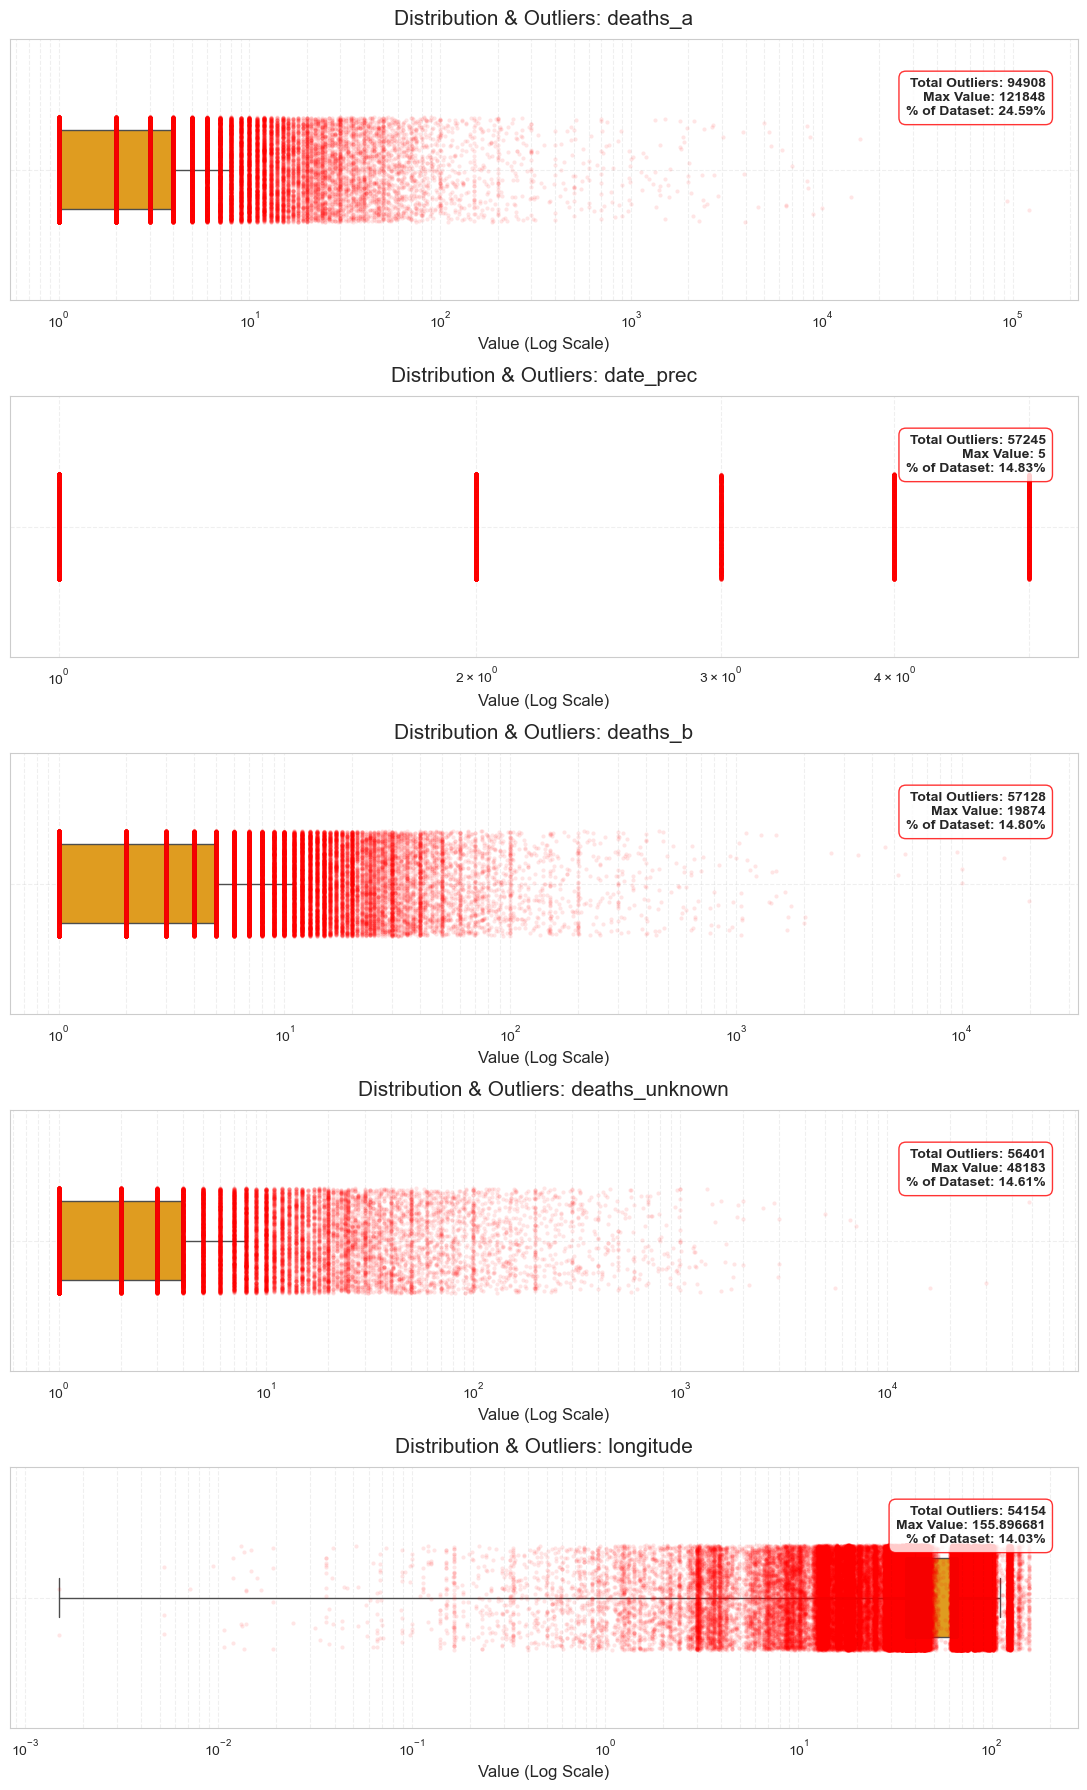

In [332]:
# We will visualize the top 5 columns with the highest percentage of outliers (after removing ID-like columns)
top5_cols = outliers_data.head(5)['Column']

fig, axes = plt.subplots(len(top5_cols), 1, figsize=(11, 18))

for i, col in enumerate(top5_cols):
    ax = axes[i]
    data_col = df_num[col].dropna()
    
    # We need to filter out 0s for the log scale to work properly on the axis
    # or use a very small value. Here we use data > 0 for the visual.
    plot_data = data_col[data_col > 0]
    
    # --- Calculate Stats for the Info Box ---
    q1 = data_col.quantile(0.25)
    q3 = data_col.quantile(0.75)
    iqr = q3 - q1
    num_outliers = ((data_col < (q1 - 1.5 * iqr)) | (data_col > (q3 + 1.5 * iqr))).sum()
    max_val = data_col.max()
    perc_outliers = (num_outliers / len(data_col)) * 100

    # 1. Base Boxplot (Orange)
    sns.boxplot(x=plot_data, ax=ax, color='orange', width=0.3, 
                flierprops={'marker': '', 'alpha':0}) 

    # 2. Stripplot (Red dots)
    sns.stripplot(x=plot_data, ax=ax, color='red', alpha=0.1, jitter=0.2, size=3)

    # 3. Logarithmic Scale
    ax.set_xscale('log')

    # 4. Titles and Labels
    ax.set_title(f'Distribution & Outliers: {col}', fontsize=15, pad=10)
    ax.set_xlabel('Value (Log Scale)', fontsize=12)

    # 5. Technical Info Box
    info_text = (f'Total Outliers: {num_outliers}\n'
                 f'Max Value: {max_val}\n'
                 f'% of Dataset: {perc_outliers:.2f}%')

    ax.text(0.97, 0.85, info_text, transform=ax.transAxes, 
            ha='right', va='top', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5', alpha=0.8))

    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\tolot\anaconda3\envs\add-env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tolot\anaconda3\envs\add-env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


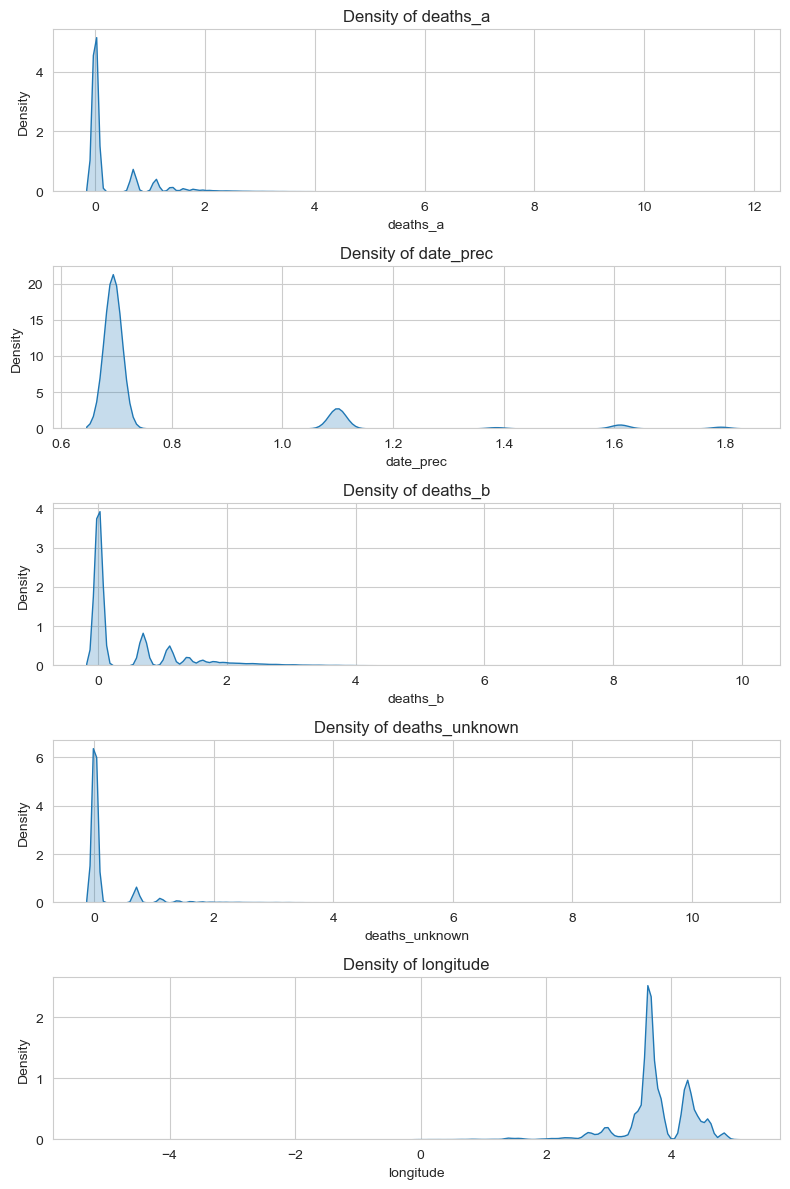

In [333]:
fig, axes = plt.subplots(len(top5_cols), 1, figsize=(8, 12))

for i, col in enumerate(top5_cols):
    sns.kdeplot(np.log1p(df_num[col]), ax=axes[i], fill=True)
    axes[i].set_title(f'Density of {col}')

plt.tight_layout()
plt.show()

###  <font color="#ff8800"> Key Features </font>

####  <font color="#00ffea"> Death </font>

In [334]:
# Deaths analysis
death_cols = ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low']

print("\n=== Deaths Statistics ===")
print(df[death_cols].describe().round(2))



=== Deaths Statistics ===
        deaths_a   deaths_b  deaths_civilians  deaths_unknown       best  \
count  385918.00  385918.00         385918.00       385918.00  385918.00   
mean        2.47       2.25              3.82            1.72      10.25   
std       254.72      53.76            178.40           99.62     347.68   
min         0.00       0.00              0.00            0.00       0.00   
25%         0.00       0.00              0.00            0.00       1.00   
50%         0.00       0.00              0.00            0.00       2.00   
75%         0.00       1.00              1.00            0.00       4.00   
max    121848.00   19874.00          40000.00        48183.00  121848.00   

            high        low  
count  385918.00  385918.00  
mean       15.12       8.54  
std       426.86     313.66  
min         0.00       0.00  
25%         1.00       1.00  
50%         2.00       2.00  
75%         5.00       4.00  
max    121848.00  121848.00  


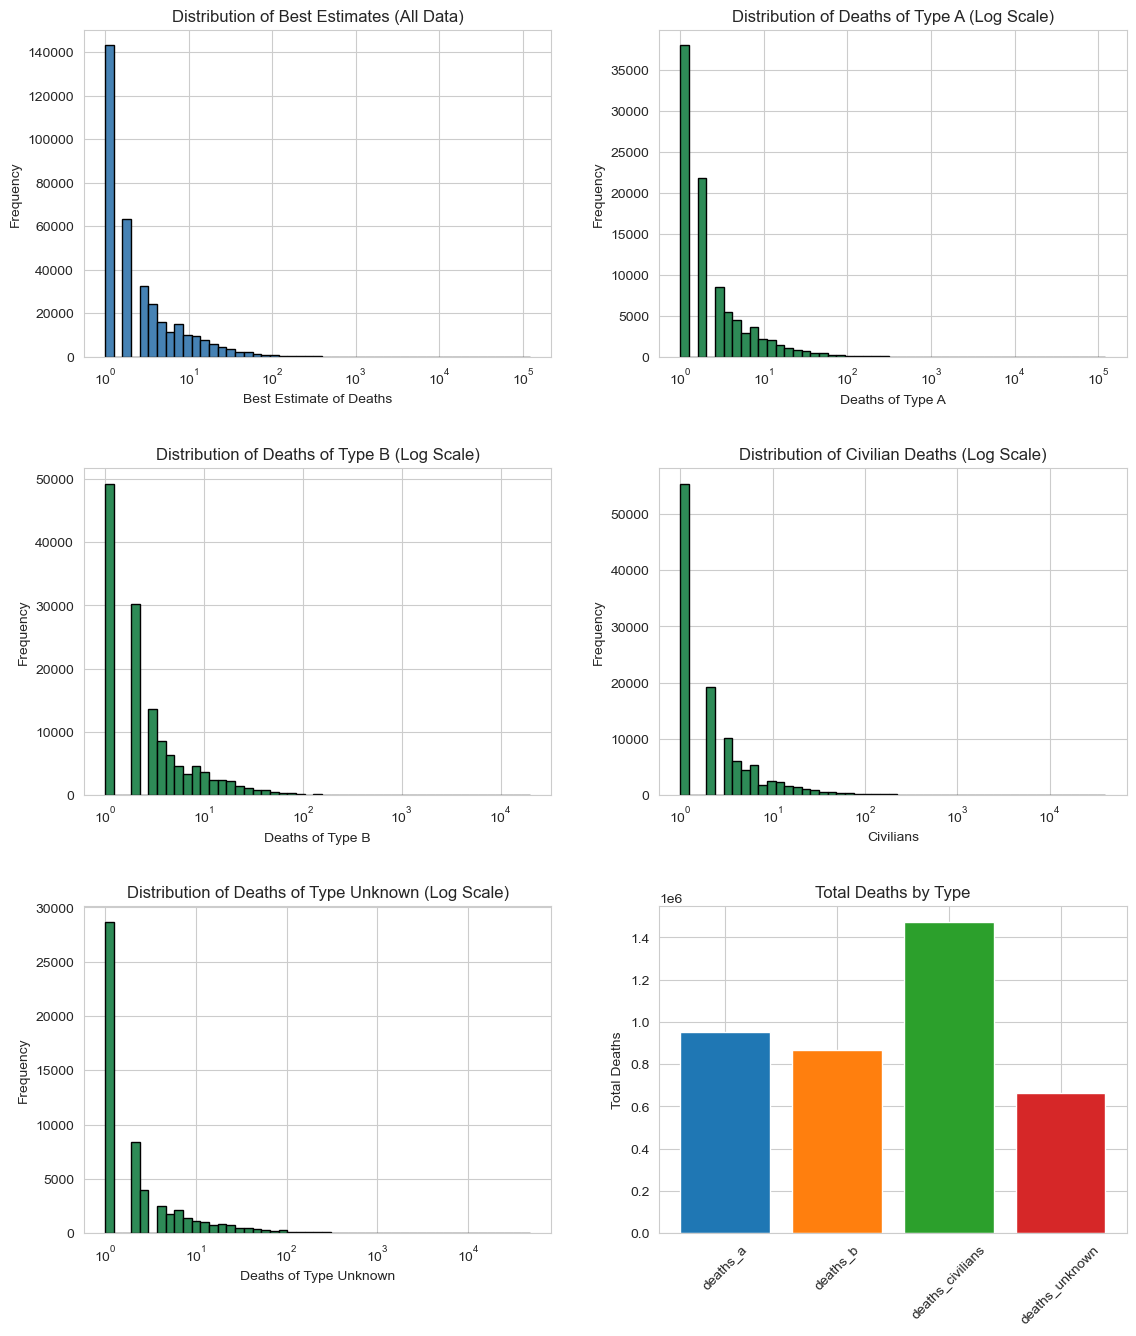

In [335]:
# Distribution of best estimates of deaths
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# Best deaths
bins = np.logspace(np.log10(df[df['best'] > 0]['best'].min()), np.log10(df[df['best'] > 0]['best'].max()), 50)
axes[0, 0].hist(df[df['best'] > 0]['best'], bins=bins, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Best Estimate of Deaths')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Best Estimates (All Data)')
#axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')

# Best deaths (log scale on x)
bins = np.logspace(np.log10(df[df['deaths_a'] > 0]['deaths_a'].min()), np.log10(df[df['deaths_a'] > 0]['deaths_a'].max()), 50)
axes[0, 1].hist(df[df['deaths_a'] > 0]['deaths_a'], bins=bins, color='seagreen', edgecolor='black')
axes[0, 1].set_xlabel('Deaths of Type A')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Deaths of Type A (Log Scale)')
#axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')

bins = np.logspace(np.log10(df[df['deaths_b'] > 0]['deaths_b'].min()), np.log10(df[df['deaths_b'] > 0]['deaths_b'].max()), 50)
axes[1, 0].hist(df[df['deaths_b'] > 0]['deaths_b'], bins=bins, color='seagreen', edgecolor='black')
axes[1, 0].set_xlabel('Deaths of Type B')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Deaths of Type B (Log Scale)')
#axes[1, 0].set_yscale('log')
axes[1, 0].set_xscale('log')

bins = np.logspace(np.log10(df[df['deaths_civilians'] > 0]['deaths_civilians'].min()), np.log10(df[df['deaths_civilians'] > 0]['deaths_civilians'].max()), 50)
axes[1, 1].hist(df[df['deaths_civilians'] > 0]['deaths_civilians'], bins=bins, color='seagreen', edgecolor='black')
axes[1, 1].set_xlabel('Civilians')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Civilian Deaths (Log Scale)')
#axes[1, 1].set_yscale('log')
axes[1, 1].set_xscale('log')

bins = np.logspace(np.log10(df[df['deaths_unknown'] > 0]['deaths_unknown'].min()), np.log10(df[df['deaths_unknown'] > 0]['deaths_unknown'].max()), 50)
axes[2, 0].hist(df[df['deaths_unknown'] > 0]['deaths_unknown'], bins=bins, color='seagreen', edgecolor='black')
axes[2, 0].set_xlabel('Deaths of Type Unknown')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title('Distribution of Deaths of Type Unknown (Log Scale)')
#axes[2, 0].set_yscale('log')
axes[2, 0].set_xscale('log')

# Deaths by type
death_by_type = df[['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown']].sum()
axes[2, 1].bar(death_by_type.index, death_by_type.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2, 1].set_ylabel('Total Deaths')
axes[2, 1].set_title('Total Deaths by Type')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(pad=3.0) 
plt.show()


####  <font color="#00ffea"> Conflict </font>

In [336]:
# Conflict analysis
conflict_cols = ['type_of_violence', 'conflict_new_id', 'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a',
              'side_b_new_id', 'side_b']

print("\n=== Conflict Statistics ===")
print(df[conflict_cols].describe().round(2))



=== Conflict Statistics ===
       type_of_violence  conflict_new_id  dyad_new_id  side_a_new_id  \
count         385918.00        385918.00    385918.00      385918.00   
mean               1.45          3893.46      6993.74         633.19   
std                0.75          5774.83      6475.38        1705.34   
min                1.00           205.00       406.00           3.00   
25%                1.00           299.00       781.00         109.00   
50%                1.00           386.00      5226.00         118.00   
75%                2.00          4979.00     14117.00         154.00   
max                3.00         16527.00     18362.00        9363.00   

       side_b_new_id  
count      385918.00  
mean         1752.30  
std          2396.03  
min             1.00  
25%           208.00  
50%           338.00  
75%          4456.00  
max          9392.00  


In [337]:
df[conflict_cols].describe(include='string').T

,count,unique,top,freq
conflict_name,385918,1529,Syria: Government,66186
dyad_name,385918,1771,Government of Syria - Syrian insurgents,66186
side_a,385918,966,Government of Syria,75181
side_b,385918,959,Syrian insurgents,66186


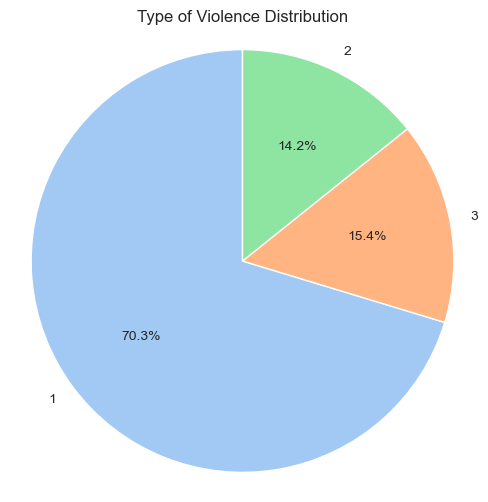

In [338]:
typ_violence_counts = df['type_of_violence'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    typ_violence_counts,
    labels=typ_violence_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

plt.title('Type of Violence Distribution')
plt.axis('equal')

plt.show()

####  <font color="#00ffea"> Information </font>

In [339]:
# Information analysis
info_cols = ['number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'event_clarity',
              'date_prec', 'date_start', 'date_end', 'year', 'active_year']

print("\n=== Information Statistics ===")
print(df[info_cols].describe().round(2))


=== Information Statistics ===
       number_of_sources  event_clarity  date_prec       year
count          385918.00      385918.00  385918.00  385918.00
mean                0.82           1.08       1.22    2012.49
std                 1.65           0.27       0.65       9.41
min                -1.00           1.00       1.00    1989.00
25%                -1.00           1.00       1.00    2007.00
50%                 1.00           1.00       1.00    2014.00
75%                 1.00           1.00       1.00    2020.00
max               361.00           2.00       5.00    2024.00


In [340]:
df[info_cols].describe(include='string').T

,count,unique,top,freq
source_article,385917,255147,"""Balkan Battlegrounds: A Military History of t...",4123
source_office,288005,24027,SOHR,29640
source_date,288005,48785,2002-11-01;2012-11-01,5410
source_headline,288000,185443,Volume I and II;Bosnian Book of the Dead,4127
source_original,341674,57447,SOHR,37691
date_start,385918,13142,2014-08-29 00:00:00.000,281
date_end,385918,13145,2014-08-29 00:00:00.000,280


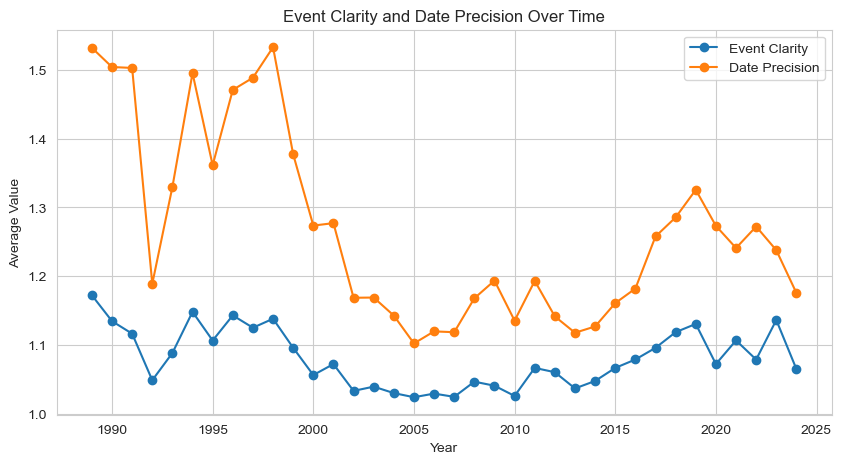

In [341]:
yearly_stats = df.groupby('year')[['event_clarity', 'date_prec']].mean().reset_index()

plt.figure(figsize=(10, 5))

plt.plot(yearly_stats['year'], yearly_stats['event_clarity'], marker='o', label='Event Clarity')
plt.plot(yearly_stats['year'], yearly_stats['date_prec'], marker='o', label='Date Precision')

plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Event Clarity and Date Precision Over Time')

plt.legend()
plt.grid(True)

plt.show()

####  <font color="#00ffea"> Location </font>

In [342]:
# Location analysis
loc_cols = ['where_prec', 'where_coordinates', 'where_description', 'country', 'country_id', 'region', 'longitude', 'latitude']

print("\n=== Location Statistics ===")
print(df[loc_cols].describe().round(2))


=== Location Statistics ===
       where_prec  country_id  longitude   latitude
count   385918.00   385918.00  385918.00  385918.00
mean         2.05      544.63      29.65      26.09
std          1.26      212.16      49.51      16.05
min          1.00        2.00    -117.30     -37.81
25%          1.00      372.00      29.17      13.36
50%          2.00      652.00      37.05      33.00
75%          3.00      700.00      62.20      35.78
max          7.00      940.00     155.90      68.98


In [343]:
df[loc_cols].describe(include='string').T

,count,unique,top,freq
where_coordinates,385918,54511,Aleppo town,4452
where_description,375675,224241,Mosul town,1125
country,385918,124,Syria,87861
region,385918,5,Middle East,122215


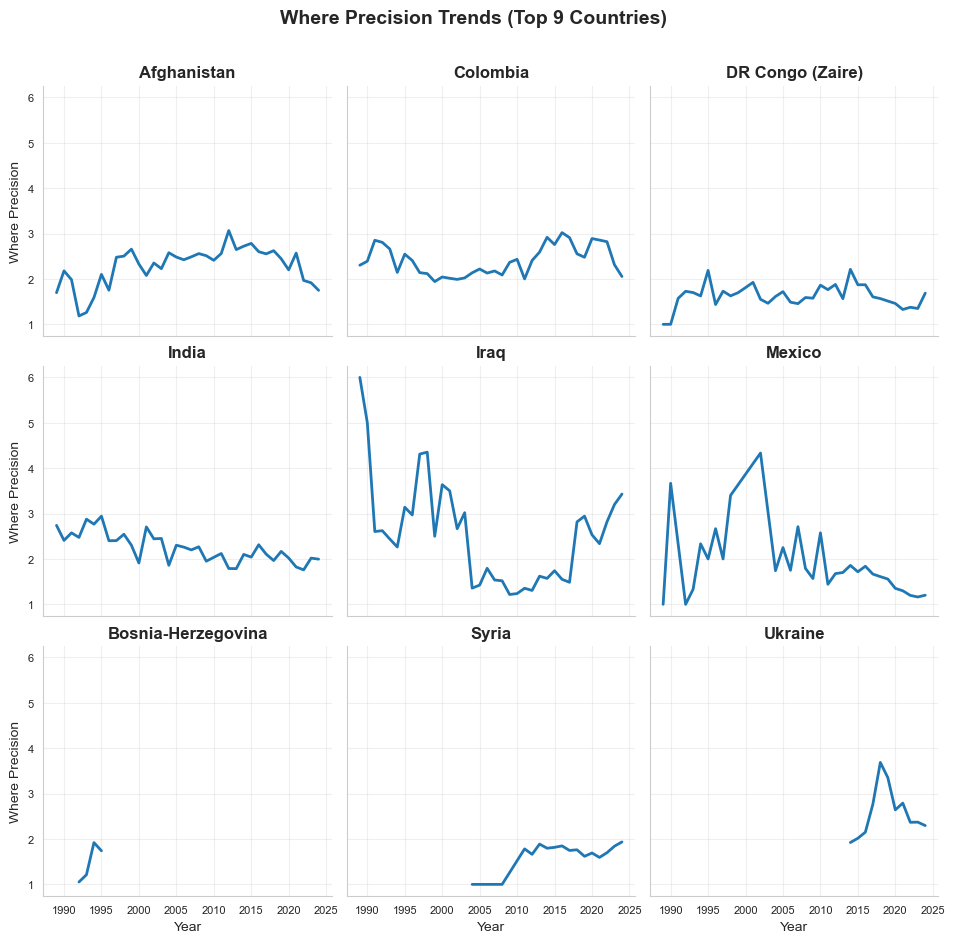

In [344]:
# Top 10 countries
top10_countries = df['country'].value_counts().head(9).index

# Filter + create year
df_top = df[df['country'].isin(top10_countries)].copy()
df_top['year'] = pd.to_datetime(df_top['date_start'], errors='coerce').dt.year

# Aggregate
country_year_stats = (
    df_top
    .groupby(['year', 'country'])['where_prec']
    .mean()
    .reset_index()
)


# Plot
g = sns.FacetGrid(
    country_year_stats,
    col='country',
    col_wrap=3,
    height=3.2,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x='year',
    y='where_prec',
    linewidth=2
)

# Titles & labels
g.set_titles("{col_name}", size=12, weight='bold')
g.set_axis_labels("Year", "Where Precision")

# Clean axes
for ax in g.axes.flatten():
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Where Precision Trends (Top 9 Countries)", fontsize=14, weight='bold')

plt.show()

####  <font color="#00ffea"> Patterns </font>

In [345]:
print(df.nlargest(10, 'best')[['region','country','type_of_violence','best', 'year', 'where_prec', 'date_prec','event_clarity', 'deaths_unknown', 'deaths_civilians']])

        region   country  type_of_violence    best  year  where_prec  \
104693  Africa  Ethiopia                 1  121848  2022           5   
104261  Africa  Ethiopia                 1  113368  2021           5   
105778  Africa  Ethiopia                 1   48183  2000           5   
222624  Africa    Rwanda                 3   40000  1994           1   
222628  Africa    Rwanda                 3   40000  1994           5   
222791  Africa    Rwanda                 3   40000  1994           1   
222033  Africa    Rwanda                 3   37000  1994           2   
105776  Africa  Ethiopia                 1   30000  1999           5   
222038  Africa    Rwanda                 3   25190  1994           2   
222773  Africa    Rwanda                 3   25000  1994           1   

        date_prec  event_clarity  deaths_unknown  deaths_civilians  
104693          5              2               0                 0  
104261          5              2               0                 0  


In [346]:
df.groupby('country')['best'].sum().sort_values(ascending=False).head(10)

country
Rwanda              794117
Ethiopia            504087
Syria               413311
Afghanistan         317793
Ukraine             245068
Mexico              141035
DR Congo (Zaire)    139381
Iraq                127241
Sudan               113439
Nigeria              73822
Name: best, dtype: int64

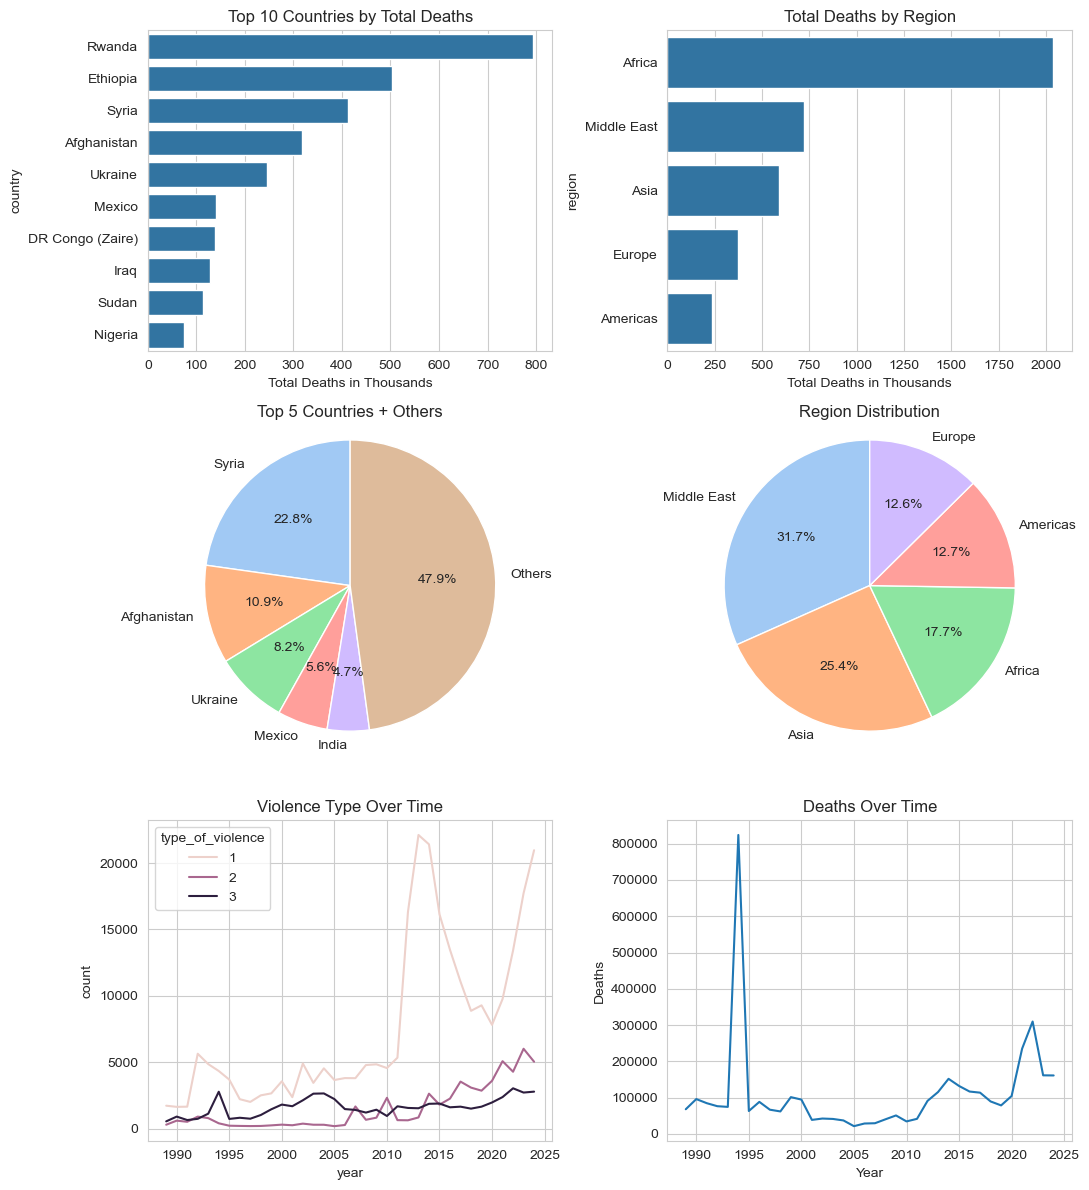

In [347]:
sns.set_style("whitegrid")

# --- 2. Top 10 countries by deaths ---
top_countries_deaths = (
    df.groupby('country')['best']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# --- 3. Top regions by deaths ---
top_regions_deaths = (
    df.groupby('region')['best']
    .sum()
    .sort_values(ascending=False)
)

# Calcular cantidades de cada especie
regions_counts = df['region'].value_counts()

# Top 5 countries and others
counts = df['country'].value_counts()

top5 = counts.head(5)
others = counts.iloc[5:].sum()

pie_data = top5.copy()
pie_data['Others'] = others

# --- PLOTS ---
fig, axes = plt.subplots(3, 2, figsize=(11, 12))

# Countries deaths
sns.barplot(
    x=(top_countries_deaths.values)/1000,  # Scale to thousands
    y=top_countries_deaths.index,
    ax=axes[0,0]
)
axes[0,0].set_title('Top 10 Countries by Total Deaths')
axes[0,0].set_xlabel('Total Deaths in Thousands')

# Regions deaths
sns.barplot(
    x=top_regions_deaths.values/1000,  # Scale to thousands
    y=top_regions_deaths.index,
    ax=axes[0,1]
)
axes[0,1].set_title('Total Deaths by Region')
axes[0,1].set_xlabel('Total Deaths in Thousands')

# --- Pie chart per Country---

axes[1, 0].pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

axes[1, 0].set_title('Top 5 Countries + Others')
axes[1, 0].axis('equal')

# --- Pie chart per Region ---
axes[1,1].pie(
    regions_counts,
    labels=regions_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

axes[1,1].set_title('Region Distribution')
axes[1,1].axis('equal')  # keep it circular

# --- 3. Violence Type Evolution ---
violence_trend = (
    df.groupby(['year', 'type_of_violence'])
    .size()
    .reset_index(name='count')
)

sns.lineplot(
    data=violence_trend,
    x='year',
    y='count',
    hue='type_of_violence',
    ax=axes[2, 0]
)
axes[2, 0].set_title('Violence Type Over Time')

deaths_trend = (
    df.groupby('year')['best']
    .sum()
    .reset_index()
)

# --- 3. Deaths Over Time ---

sns.lineplot(
    data=deaths_trend,
    x='year',
    y='best',
    ax=axes[2, 1]
)

axes[2, 1].set_title('Deaths Over Time')
axes[2, 1].set_xlabel('Year')
axes[2, 1].set_ylabel('Deaths')

plt.tight_layout()
plt.show()

## <font color="#cc00ff"> Dataset Summary – Exploratory Data Analysis (EDA) </font>

---

### **Data Quality and Completeness**

- Missing Values: The dataset is largely complete for core identifiers. However, the column gwnob has a missing rate exceeding 90%, and several source-related columns (e.g., source_office, source_headline) are missing roughly 25% of their data.

- Outliers: Statistical analysis reveals a high percentage of outliers in death counts, particularly for deaths_a (24.59%). This is expected in conflict data where a few massive events (like the Rwandan Genocide or the Ethiopian-Eritrean war) drastically exceed the typical event scale of 1–4 deaths.

- Precision: Event clarity and date precision have generally improved over time, though significant fluctuations exist. Location precision (where_prec) averages 2.05, indicating most events are localized to a second-order administrative division or better.

### **Statistical Distribution of Deaths**

The data is highly right-skewed, with a "long tail" distribution.

- Scale of Events: While the median (50%) death toll for the "best" estimate is only 2.0, the maximum reaches 121,848.

- Death Categories: deaths_civilians represents the highest total volume of fatalities compared to other specific categories like deaths_a or deaths_b.

- Total Casualties: Africa and the Middle East are the regions with the highest total fatalities.

### **Conflict and Violence Insights**

Types of Violence: State-based conflict (Type 1) is the most prevalent, accounting for 70.3% of the recorded events. One-sided violence (Type 3) and non-state conflict (Type 2) follow at 15.4% and 14.2% respectively.

**Top Conflict Zones** (by Total Deaths):

- Rwanda: ~794,000 (Dominated by the 1994 genocide).

- Ethiopia: ~504,000.

- Syria: ~413,000.

- Afghanistan: ~318,000.

Temporal Trends: There is a massive spike in fatalities in 1994 (Rwanda). A secondary sustained increase in event frequency and deaths began around 2011–2012, corresponding with the Syrian Civil War and the rise of ISIS, with another significant peak in recent years (2022 onwards) likely tied to the conflict in Ukraine.

### **Key Entities**

Most Frequent Conflict: Syria: Government is the most frequently appearing conflict in the logs (over 66,000 entries).

- **Primary Actors**: The Government of Syria and Syrian Insurgents are the most frequently recorded "Side A" and "Side B" actors, respectively.

- **Information Sources**: The Syrian Observatory for Human Rights (SOHR) is a primary contributor to the dataset's source material.


##  <font color="#fbff00">3. Preprocessing and Cleaning </font>

###  <font color="#ff8800"> Missing Values </font>

In [348]:
df2 = df.copy()

# Convert to datetime
df2['source_date'] = pd.to_datetime(
    df['source_date'], 
    format='%Y-%m-%d', # Codebook Format: YYYY-MM-DD
    errors='coerce', 
    utc=True
)

# Create flag BEFORE replacing
df2['source_date_missing_flag'] = (df['source_date'] == pd.Timestamp('1753-01-01')).astype(int)

# replace with NaT
df2.loc[df2['source_date'] == pd.Timestamp('1753-01-01'), 'source_date'] = pd.NaT

This code creates a copy of the dataset and analyzes columns with missing values. For each column, it calculates the percentage of missing data. If the percentage is 5% or higher, it adds a new binary column indicating whether each value is missing (1) or not (0). Some columns (`gwnob`, `gwnoa`) are explicitly excluded from this process. Columns with less than 5% missing values are skipped.

In [349]:
df_aux = df2.copy()

missing_cols = df_aux.columns[df_aux.isna().any()]
cols_to_exclude = ['gwnob', 'gwnoa']

for col in missing_cols:

    if col in cols_to_exclude:
        print(f"Excluded: {col} - specified by user")
        continue
    
    null_percentage = df_aux[col].isna().mean() # Returns a value between 0 and 1
    
    if null_percentage >= 0.05:
        df_aux[col + '_missing'] = df_aux[col].isna().astype(int)
        print(f"Added: {col} ({null_percentage:.2%})")
    else:
        print(f"Skipped: {col} ({null_percentage:.2%}) - below threshold")


Skipped: source_article (0.00%) - below threshold
Added: source_office (25.37%)
Added: source_date (45.28%)
Added: source_headline (25.37%)
Added: source_original (11.46%)
Skipped: where_description (2.65%) - below threshold
Added: adm_1 (5.07%)
Added: adm_2 (18.13%)
Excluded: gwnoa - specified by user
Excluded: gwnob - specified by user


 <font color="#ff0000"> **IMPORTANT**  </font>

- **source_article** just 1 null value

- **where_description** null values amount < 3%

- **gwnob** and **gwnoa** act like a bool type

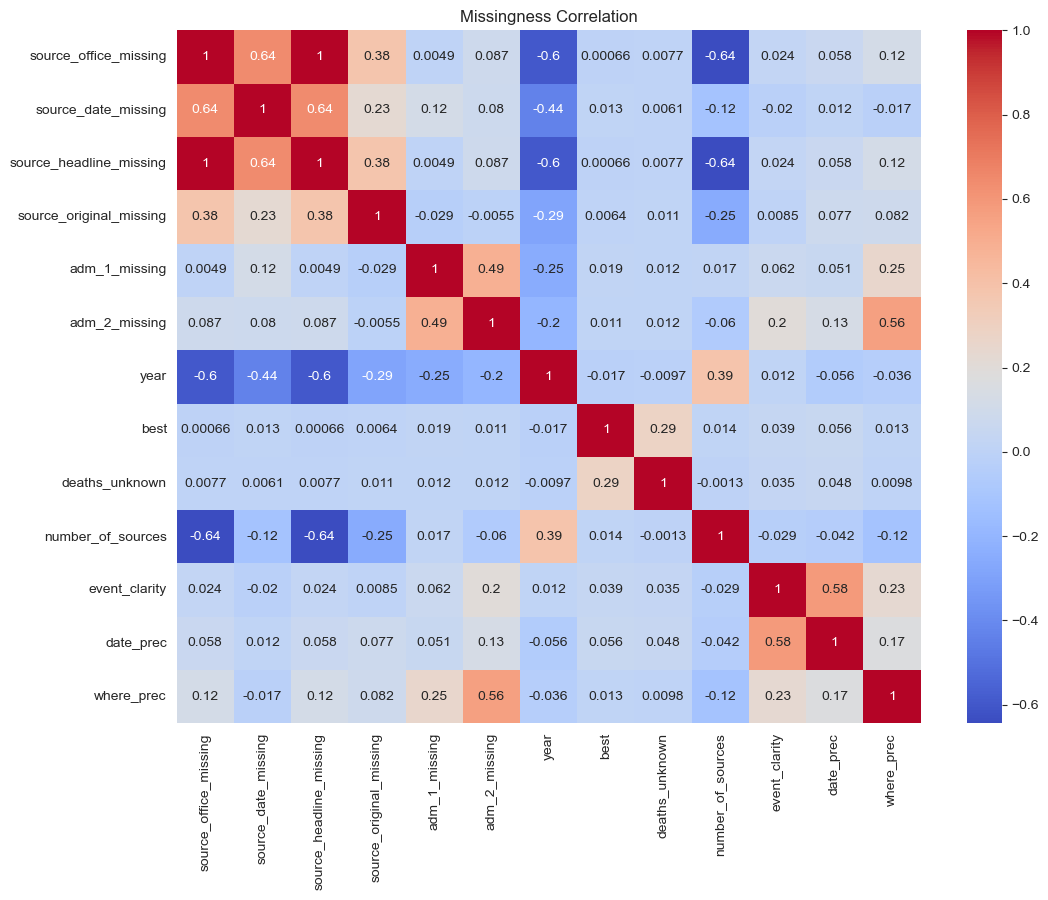

In [350]:
# 1. Dynamically find only the columns that actually exist and end with '_missing'
actual_missing_cols = [col for col in df_aux.columns if col.endswith('_missing')]

# 2. Add your target variables ('year' and 'best') to that list
cols_to_correlate = actual_missing_cols + ['year', 'best', 'deaths_unknown', 'number_of_sources', 'event_clarity', 'date_prec', 'where_prec']

# 3. Run the correlation
missing_corr = df_aux[cols_to_correlate].corr()

plt.figure(figsize=(12,9))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm')
plt.title('Missingness Correlation')
plt.show()

 <font color="#ff0000"> **IMPORTANT**  </font>

Before proceeding with the analysis of missing values and outliers, the features `latitude` and `longitude` were removed from the dataset.

Although these variables contain geographic information, they were not relevant for the scope of the current analysis, which focuses on temporal patterns, conflict characteristics, and aggregated trends at the country and region level. Using raw coordinates would require additional spatial processing (e.g., clustering or geospatial modeling) to extract meaningful insights.

Additionally, these features may appear to contain outliers when using standard statistical methods such as IQR. However, this is not due to data quality issues, but rather the natural range and distribution of geographic coordinates. Therefore, treating them as typical numerical variables for outlier analysis would be misleading.

For these reasons, `latitude` and `longitude` were excluded to simplify the analysis and avoid introducing noise or misinterpretation.

In [351]:
df2 = df.copy()
drop = ['latitude', 'longitude']
df2.drop(columns=drop, errors='ignore', inplace=True)

 <font color="#ff0000"> **IMPORTANT**  </font>
 
We create the following flag with the goal of determine which sample is considered "old". In this case, based on the information provided by the dataset document, any sample taken **BEFORE** 2013 is considered old. This step is very important because features like 'source_headline', 'source_date', 'source_office' are empty for data older than 2013

In [352]:
df2['is_old_data'] = (df['year'] < 2013).astype(int)

We add a treatment for the features with significant missing values

In [353]:
# Create a flag for missing source information
source_cols = ['source_headline', 'source_date', 'source_office']
mask_all_missing = df[source_cols].isnull().all(axis=1)
df2['source_missing_flag'] = mask_all_missing.astype(int)

# Create a flag for missing source information expected in old data
df2['source_missing_expected'] = (
    mask_all_missing & (df2['is_old_data'] == 1)
).astype(int)

# Fill missing values in source_headline and source_office with 'Old_NoData' for old data and 'Missing' for new data
df2['source_headline'] = df['source_headline'].fillna(
    df2['is_old_data'].map({1: 'Old_NoData', 0: 'Missing'}))
# Fill missing values in source_headline and source_office with 'Old_NoData' for old data and 'Missing' for new data
df2['source_office'] = df['source_office'].fillna(
    df2['is_old_data'].map({1: 'Old_NoData', 0: 'Missing'}))

# Create flags for missing administrative divisions
df2['adm1_missing_flag'] = df2['adm_1'].isnull().astype(int)
df2['adm2_missing_flag'] = df2['adm_2'].isnull().astype(int)
# Fill missing values in location and source columns with 'Unknown'
df2['adm_1'] = df2['adm_1'].fillna('Unknown')
df2['adm_2'] = df2['adm_2'].fillna('Unknown')

# Create a flag for missing source_original
df2['source_original_missing_flag'] = df2['source_original'].isnull().astype(int)
# Fill missing values in source_original with 'Unknown'
df2['source_original'] = df2['source_original'].fillna('Unknown')

# Fill missing values in where_description with 'Unknown'
df2['where_description'] = df2['where_description'].fillna('Unknown')

# Drop rows where source_article is missing, as it's a key variable for analysis
# In this case, is just one row
df2 = df2.dropna(subset=['source_article'])

###  <font color="#ff8800"> Outliers </font>

We calculate again the outliers values and determine the root causes

In [354]:
# IQR Outliers
print("\n=== Numeric Features Outliers ===")
df_num_clean = df2.select_dtypes(include="number")
df_num_clean = df_num_clean.loc[:, ~df_num_clean.columns.str.contains('id', case=False)]

Q1 = df_num_clean.quantile(0.25)
Q3 = df_num_clean.quantile(0.75)
IQR = Q3 - Q1

outliers_mask_clean = ((df_num_clean < (Q1 - 1.5 * IQR)) | (df_num_clean > (Q3 + 1.5 * IQR)))

# Filter columns with more than 10% outliers

outliers_data_clean = pd.DataFrame({
    'Outliers_count': outliers_mask_clean.sum(),
    'Outliers_Percentage': (outliers_mask_clean.sum() / len(df2) * 100).round(2)
})

outliers_data_clean = outliers_data_clean.reset_index().rename(columns={'index': 'Column'})

outliers_data_clean = outliers_data_clean[outliers_data_clean['Outliers_Percentage'] > 10].sort_values('Outliers_count', ascending=False)
print(outliers_data_clean.head(10))


=== Numeric Features Outliers ===
                          Column  Outliers_count  Outliers_Percentage
16       source_missing_expected           95431                24.73
6                       deaths_a           94908                24.59
18             adm2_missing_flag           69976                18.13
5                      date_prec           57244                14.83
7                       deaths_b           57128                14.80
9                 deaths_unknown           56400                14.61
10                          best           50209                13.01
12                           low           46614                12.08
11                          high           45916                11.90
19  source_original_missing_flag           44244                11.46


In [355]:
df_model = df2.copy()

for col in death_cols:
    df_model[col] = np.log1p(df_model[col])

###  <font color="#ff8800"> Split </font>

In [356]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_model, test_size=0.2, random_state=42)

## <font color="#cc00ff">  Missing Data Analysis </font>

The dataset exhibits several distinct patterns of missing data, which provide important insights into both data quality and the underlying data generation process.

A group of source-related variables (`source_headline`, `source_date`, `source_office`) presents approximately 25% missing values. These variables show a strong dependency in their missingness, as they tend to be missing simultaneously. However, further analysis reveals that this pattern is not purely random nor strictly MNAR, but largely structural and time-dependent. In particular, these variables are **only consistently available for more recent events (post-2013)**, meaning that their absence in earlier records reflects limitations in historical data collection rather than true missing information.

Therefore, this missingness is better interpreted as a combination of structural missingness and temporal dependency, rather than purely MNAR. To properly capture this behavior, the missingness is explicitly modeled through feature engineering, distinguishing between expected (older data) and unexpected (recent data) absence of information.

Administrative location variables (`adm_1`, `adm_2`) show moderate levels of missingness (approximately 5–18%), with some correlation between them. Unlike source-related variables, this missingness does not follow a clear temporal pattern and is likely associated with limitations in geographic precision or reporting conditions. As such, it is reasonable to classify this as Missing At Random (MAR). Instead of removing these observations, missingness is preserved through indicator variables, while categorical imputation is applied to enable model compatibility.

Other variables, such as `where_description`, contain a very small proportion of missing values (below 3%). Given the low impact and the potential importance of these records (e.g., events with significant fatalities), these observations are retained and imputed without aggressive filtering.

Rather than discarding incomplete observations, the adopted strategy consists of:

- Preserving all available data to avoid losing potentially critical information
- Explicitly encoding missingness through indicator features
- Applying appropriate imputation strategies depending on the variable type (categorical, textual, or temporal)
- Leveraging domain knowledge to distinguish between structural and non-structural missingness


### <font color="#d193e0">  Missing Data Interpretation (Structural Missingness)</font>

Some variables in the dataset, specifically `gwnoa` and `gwnob`, exhibit high levels of missing values. However, this missingness is not due to data quality issues but is instead structural and defined by the dataset design.

These variables represent the Gleditsch and Ward country codes for the actors involved in a conflict, and are only populated when the corresponding side is a state. If a side is a non-state actor (e.g., rebel groups, militias), the value is intentionally left empty.

Therefore, the missing values in these variables should be interpreted as meaningful information rather than absence of data. For example, the high percentage of missing values in `gwnob` indicates that in most conflicts, Side B is a non-state actor. This reflects the real-world prevalence of asymmetric conflicts between governments and non-state groups.

To better utilize this information, new binary features will be created to indicate whether each side is a state actor. Additionally, a combined feature will be derived to classify the type of conflict (state vs state, state vs non-state, or non-state vs non-state).

This transformation allows the model to capture the structure of conflicts more effectively while avoiding misleading interpretations of missing data.

## <font color="#cc00ff"> Outlier Analysis Interpretation </font>

The outlier detection was performed using the IQR method on numerical features. However, it is important to interpret these results carefully, as not all detected "outliers" represent errors or anomalies in the data.

First, some variables such as `date_prec` and `event_clarity` are ordinal rather than continuous. Since they take a limited set of discrete values representing categories or levels of precision, applying IQR-based outlier detection to them is not appropriate. The percentages reported for these variables do not reflect meaningful outliers and should be disregarded.

In contrast, variables related to fatalities (`deaths_a`, `deaths_b`, `deaths_civilians`, `deaths_unknown`, `best`, `low`, `high`) show a high proportion of detected outliers (ranging from ~10% to ~25%). This is expected and does not indicate data quality issues. Conflict-related data typically follows a highly skewed, heavy-tailed distribution, where most events involve few deaths, while a small number of events account for extremely large fatalities (e.g., wars, genocides, or major attacks).

Therefore, these "outliers" represent real, high-impact events rather than noise or errors. Removing them would lead to a significant loss of critical information and bias the analysis.

Instead of removing these values, a more appropriate approach is to apply transformations (such as logarithmic scaling) to reduce skewness and improve interpretability while preserving the underlying information.

In summary:
- Outliers in ordinal variables should be ignored due to methodological limitations.
- Outliers in death-related variables are meaningful and should be retained.
- The presence of many outliers reflects the real-world nature of conflict data, not data quality issues.

## <font color="#cc00ff"> Problem Definition </font>

---

## Supervised Learning Approach

Based on the characteristics of the dataset, a **classification problem** is proposed.

The objective is to predict the **intensity level of conflict events**, which will be represented by a target variable called `intensity`.

### Target Variable

- The variable `intensity` will be **defined and constructed in later steps**.
- It will be derived from existing features in the dataset (e.g., variables related to fatalities).
- The goal is to transform continuous or raw information into **discrete categories** (e.g., low, medium, high intensity), making it suitable for a classification task.

---

## Objective

Develop a model capable of classifying conflict events according to their intensity level, enabling a structured and interpretable understanding of event severity.

##  <font color="#fbff00">4. Feature Engineering </font>

 <font color="#ff0000"> **IMPORTANT**  </font>

 **Removing Identifier Columns**

Given the chosen classification problem, identifier-like columns were removed from the dataset.

The following variables:
`id`, `conflict_new_id`, `dyad_new_id`, `side_a_new_id`, `side_b_new_id`, and `country_id`

were excluded because they act as **unique identifiers** rather than meaningful features. These columns do not provide predictive value for the target variable (`intensity`) and could negatively impact the model by introducing noise or artificial patterns.

Removing them helps ensure that the model learns from **relevant information** instead of arbitrary identifiers.

 <font color="#ff0000"> **IMPORTANT**  </font>

As we mentioned before, `gwnoa` and `gwnob` represent the Gleditsch and Ward country codes for the actors involved in a conflict, and are only populated when the corresponding side is a state. If a side is a non-state actor (e.g., rebel groups, militias), the value is intentionally left empty. This reflects

To better utilize this information, new binary features will be created to indicate whether each side is a state actor. Additionally, a combined feature will be derived to classify the type of conflict (state vs state, state vs non-state, or non-state vs non-state).

This transformation allows the model to capture the structure of conflicts more effectively while avoiding misleading interpretations of missing data.

We also add civilian ratio as new feature

###  <font color="#ff8800"> Data Test + Pipeline </font>

In [357]:
import warnings

class DataPreprocessor:
    def __init__(self):
        # We will store frequency encoding maps here after fitting
        # We also want to store the reference columns for violence and region dummies to ensure consistency between train and test
        self.freq_maps = {}
        self.violence_cols = None
        self.region_cols = None

        # id like columns that we know should never be used as features
        self.drop_ids = [
            'id','conflict_new_id','dyad_new_id',
            'side_a_new_id','side_b_new_id','country_id'
        ]

        # leakage columns that we know should never be used as features
        self.drop_leakage = [
            'best','low','high',
            'deaths_a','deaths_b',
            'deaths_civilians','deaths_unknown'
        ]

        # columns that are mostly text and some are used for feature engineering, so we drop them at the end to be safe
        self.drop_others = [
            'region',
            'source_article',
            'source_headline',
            'where_description',
            'conflict_name',
            'dyad_name',
            'side_a',
            'side_b',
            'source_date',
            'where_coordinates'
        ]

    def fit(self, df):
        df_fit = df.copy()

        # Frequency encoding maps
        for col in ['source_office', 'source_original', 'country', 'adm_1', 'adm_2']:
            self.freq_maps[col] = df_fit[col].value_counts(normalize=True)

        # Violence dummies reference
        self.violence_cols = pd.get_dummies(
            df_fit['type_of_violence'],
            prefix='violence',
            drop_first=True
        ).columns

        # Region dummies reference
        self.region_cols = pd.get_dummies(
            df_fit['region'],
            prefix='region'
        ).columns

        return self

    def transform(self, df):
        df = df.copy()

        # =========================
        # 1. DROP IDS
        # =========================
        df = df.drop(columns=self.drop_ids, errors='ignore')

        # =========================
        # 2. STATE FLAGS
        # =========================
        df['side_a_is_state'] = df['gwnoa'].notnull().astype(int)
        df['side_b_is_state'] = df['gwnob'].notnull().astype(int)

        # =========================
        # 3. VIOLENCE ENCODING
        # =========================
        violence_dummies = pd.get_dummies(
            df['type_of_violence'],
            prefix='violence',
            drop_first=True
        ).reindex(columns=self.violence_cols, fill_value=0)

        df = pd.concat([df, violence_dummies], axis=1)
        df = df.drop(columns=['gwnoa', 'gwnob', 'type_of_violence'], errors='ignore')

        # =========================
        # 4. TARGET 
        # =========================
        def classify(x):
            if x <= np.log1p(5):
                return 0
            elif x <= np.log1p(50):
                return 1
            elif x <= np.log1p(500):
                return 2
            else:
                return 3
        # just in case target column is missing, we dont want the code to break, but if it exists we create the encoded version
        if 'best' in df.columns:
            df['intensity_encoded'] = df['best'].apply(classify)
        else:
            warnings.warn("Column 'best' is missing. 'intensity_encoded' was NOT created. ", UserWarning)

        # =========================
        # 5. DATE FEATURES
        # =========================
        df['date_start'] = pd.to_datetime(df.get('date_start'), errors='coerce')
        df['date_end'] = pd.to_datetime(df.get('date_end'), errors='coerce')

        df['event_duration'] = (df['date_end'] - df['date_start']).dt.days.clip(lower=0)
        df['is_multi_day_event'] = (df['event_duration'] > 0).astype(int)

        df['is_precise_location'] = df['where_prec'].isin([1, 2]).astype(int)

        df['event_month'] = df['date_start'].dt.month
        df['month_sin'] = np.sin(2 * np.pi * df['event_month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['event_month'] / 12)

        df['is_exact_date'] = (df['date_prec'] == 1).astype(int)

        # After creating the features, we can drop the original date and precision columns
        df = df.drop(
            columns=['date_start', 'date_end', 'event_month', 'where_prec', 'where_coordinates', 'date_prec'],
            errors='ignore'
        )

        # =========================
        # 6. FREQUENCY ENCODING
        # =========================
        for col in ['source_office', 'source_original', 'country', 'adm_1', 'adm_2']:
            df[col + '_freq'] = df[col].map(self.freq_maps[col]).fillna(0)

        # We can drop the original columns after encoding
        df = df.drop(
            columns=['source_office', 'source_original', 'country', 'adm_1', 'adm_2'],
            errors='ignore'
        )

        # =========================
        # 7. REGION ENCODING
        # =========================
        region_dummies = pd.get_dummies(
            df['region'],
            prefix='region'
        ).reindex(columns=self.region_cols, fill_value=0)

        df = pd.concat([df, region_dummies], axis=1)

        # =========================
        # 8. CLEANUP
        # =========================
        # We drop text columns at the end to be safe, since some of them are used for feature engineering (like region or where_coordinates)
        df = df.drop(columns=self.drop_others, errors='ignore')
        df = df.drop(columns=self.drop_leakage, errors='ignore')

        # =========================
        # 9. FIX VALUES
        # =========================
        df['number_of_sources'] = df['number_of_sources'].replace(-1, 0)

        # =========================
        # 10. LOG TRANSFORM
        # =========================
        df['number_of_sources'] = np.log1p(df['number_of_sources'])
        df['event_duration'] = np.log1p(df['event_duration'])

        return df

In [358]:
# 1. Create preprocessor instance
preprocessor = DataPreprocessor()

# 2. fit on training data
preprocessor.fit(df_train)

# 3. transform both train and test
df_train_final = preprocessor.transform(df_train)
df_test_final  = preprocessor.transform(df_test)
print("Train shape after preprocessing:", df_train_final.shape)
print("Test shape after preprocessing:", df_test_final.shape)

Train shape after preprocessing: (308733, 31)
Test shape after preprocessing: (77184, 31)


In [359]:
# just to check that both have the same columns after transformation
print(df_train_final.columns.equals(df_test_final.columns))

True


##  <font color="#ff00bf">Features Summary </font>

### 1. **Conflict & Actor Metadata**:
These features define who is fighting and what kind of violence is occurring.
- **type_of_violence**: Categorizes the event into one of three mutually exclusive types:
    - 1 (State-based): A conflict where at least one side is a government. Example: Government of Colombia vs. FARC.
    - 2 (Non-state): Fighting between two organized groups, neither of which is a government. Example: Two rival cartels or ethnic militias fighting each other.
    - 3 (One-sided): An organized group (government or rebel) attacking unarmed civilians. Example: An extremist group attacking a village.side_a / side_b: The names of the two parties in the "dyad" (pair).In State-based, side_a is always the Government.In One-sided, side_b is always listed as "civilians".
- **side_a / side_b**: The names of the two parties in the "dyad" (pair). In State-based, side_a is always the Government. In One-sided, side_b is always listed as "civilians".
- **conflict_new_id / dyad_new_id**: Numerical "tracking codes".
    - Conflict ID: Groups all events related to the same core issue (the "War").
    - Dyad ID: Identifies the specific pair of opponents. A single conflict can have multiple dyads if different rebel groups fight the same government over the same issue.
- **adm_1**: Name of the first-order (largest) administrative division (e.g., Province).
- **adm_2**: Name of the second-order administrative division (e.g., District).

- **gwnoa / gwnob**: The Gleditsch and Ward country code. This is a standard numeric ID for recognized states (e.g., France = 220). It is empty if the actor is not a state government (like a rebel group).
- **active_year**: A binary flag (1 or 0). It is 1 if the conflict resulted in at least 25 deaths during that specific calendar year.

### 2. **Geographical & Temporal Features**: These features explain where and when the violence happened.
- **country**: Name of the country in which the event took place.
- **region**: The broad geographic region of the event: Africa, Americas, Asia, Europe, or Middle East.
- **where_coordinates**: The specific name of the location (town, village, etc.)
- **latitude / longitude**: The exact GPS-style coordinates
- **where_prec** : The precision of the location on a scale of 1 to 7.
    - 1: Exact location is known.
    - 4: Only the province (ADM1) is known.
    - 6: Only the country is known.
- **date_start / date_end**: The timeframe of the incident. If the exact day is known, these dates are the same.
- **date_prec**: How accurately the date is known.
    - 1: Exact day.
    - 5: Only the year is known.


### 3. **Fatality Figures** These features provide the "death toll" for the event. To handle reporting uncertainty, UCDP provides an interval.
- **best**: The most reliable and likely estimate of total deaths.
- **high / low**: The highest and lowest reliable numbers found in source reports.
- **deaths_civilians**: Specifically tracks deaths of unarmed people.
    - In One-sided violence, this is the main fatality count.
    - In State-based/Non-state, this represents "collateral damage" from the fighting.

### 4. **Information Sources (Data Provenance)** Critical for understanding the origin and reliability of the reported incident.
- **number_of_sources**: Total sources consulted for the event. Note: Available for data since 2013; older data defaults to -1.
- **source_article**: References to names, dates, and titles of source materials; available for all events.
- **source_office**: The organizations publishing the text (e.g., Reuters, BBC); field is empty for older data.
- **source_date**: Publication date of the source; defaults to 1753-01-01 if missing.
- **source_headline**: The title of the source material.source_original: The original source of the info (e.g., "police", "eyewitnesses", "rebel spokesman").

### 5. **Data Quality Features**
- **event_clarity**:
    - 1 (High): A specific, clear incident. Example: "A bomb at a market on Tuesday."
    - 2 (Low): An aggregate report that cannot be broken down. Example: "20 people died in various clashes last week." 